# Notebook 03 — UN Comtrade API Exploration

**Purpose:** Fetch Malaysia palm oil export volumes to India and China (2015–2025)  
**Source:** UN Comtrade API (`comtradeapicall` + direct `requests`)  
**Commodity:** HS 1511 — All palm oil (crude + refined)  
**Flow:** Malaysia → India, Malaysia → China (Exports only)  
**Frequency:** Annual only — Malaysia does not submit monthly data to Comtrade  

---

## 1. Imports and Configuration

In [1]:
import os
import time

import comtradeapicall
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv

# Load API key from .env file — never hardcode keys in notebooks
load_dotenv()
API_KEY = os.getenv("COMTRADE_API_KEY")

# Confirm key loaded (prints True/False, not the actual key)
print("API key loaded:", API_KEY is not None)

API key loaded: True


## 2. Verify Country Codes

**Always verify Comtrade country codes directly from the official reference files.**  
Never assume — some codes are expired (e.g. India code 356 expired in 1974).  

Reference files:  
- Reporters: https://comtradeapi.un.org/files/v1/app/reference/Reporters.json  
- Partners: https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json

In [2]:
# Fetch official reference tables from Comtrade
reporters = requests.get(
    "https://comtradeapi.un.org/files/v1/app/reference/Reporters.json"
).json()["results"]

partners = requests.get(
    "https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json"
).json()["results"]

'''
{
    "results": [
        {"reporterCode": 4, "reporterDesc": "Afghanistan", ...},
        {"reporterCode": 8, "reporterDesc": "Albania", ...},
        ...
    ]
}
'''

df_reporters = pd.DataFrame(reporters)
df_partners  = pd.DataFrame(partners)

# Search for Malaysia, India, China
# NOTE: partner columns use capital 'P' (PartnerCode, PartnerDesc) — inconsistent UN naming
print("=== REPORTERS (who submits the trade data) ===")
print(df_reporters[
    df_reporters["reporterDesc"].str.contains("Malaysia|India|China", case=False, na=False)
][["reporterCode", "reporterDesc"]])

print("\n=== PARTNERS (destination countries) ===")
print(df_partners[
    df_partners["PartnerDesc"].str.contains("Malaysia|India|China", case=False, na=False)
][["PartnerCode", "PartnerDesc"]])

=== REPORTERS (who submits the trade data) ===
     reporterCode                  reporterDesc
44            156                         China
45            344          China, Hong Kong SAR
46            446              China, Macao SAR
106           699                         India
107           356               India (...1974)
132           458                      Malaysia
173           459  Peninsula Malaysia (...1963)

=== PARTNERS (destination countries) ===
     PartnerCode                              PartnerDesc
36            86                   Br. Indian Ocean Terr.
55           156                                    China
56           344                     China, Hong Kong SAR
57           446                         China, Macao SAR
127          699                                    India
128          356                          India (...1974)
158          458                                 Malaysia
209          459             Peninsula Malaysia (...1963)
247  

In [12]:
# Confirmed country codes — store as named constants
# India = 699 (NOT 356 — that code expired in 1974)
MALAYSIA_CODE = "458"
INDIA_CODE    = "699"
CHINA_CODE    = "156"

print("Country codes confirmed:")
print(f"  Malaysia (reporter): {MALAYSIA_CODE}")
print(f"  India    (partner) : {INDIA_CODE}")
print(f"  China    (partner) : {CHINA_CODE}")

Country codes confirmed:
  Malaysia (reporter): 458
  India    (partner) : 699
  China    (partner) : 156


## 3. Commodity Code Decision

Initially tried `151110` (crude palm oil only) — China volumes returned near-zero.  
Root cause: Malaysia exports mostly **refined** palm oil to China, not crude.  
India buys both crude and refined.

**Decision:** Use HS `1511` (all palm oil) for both countries so India and China are compared on the same basis.

In [ ]:
# Commodity code
# 151110 = crude palm oil only  → China near-zero (wrong)
# 1511   = all palm oil         → realistic volumes for both countries
CMD_CODE = "1511"

print(f"Using commodity code: {CMD_CODE} (all palm oil, crude + refined)")

Using commodity code: 1511 (all palm oil, crude + refined)


## 4. Fetch Data from Comtrade API

Malaysia only submits annual data to Comtrade (not monthly).  
We loop year-by-year with a 1-second pause between calls to be polite to the API.

In [ ]:
def fetch_comtrade_annual(reporter, partner, cmd_code, start_year, end_year):
    """
    Fetch annual Comtrade export data for a reporter-partner-commodity combination.
    Loops year by year to stay within API limits.

    Parameters
    ----------
    reporter   : str  — Comtrade reporter country code
    partner    : str  — Comtrade partner country code
    cmd_code   : str  — HS commodity code
    start_year : int  — first year to fetch (inclusive)
    end_year   : int  — last year to fetch (inclusive)

    Returns
    -------
    pd.DataFrame — raw Comtrade records, all years concatenated
    """
    all_records = []

    for year in range(start_year, end_year + 1):
        r = requests.get(
            "https://comtradeapi.un.org/data/v1/get/C/A/HS",
            params={
                "reporterCode":     reporter,
                "partnerCode":      partner,
                "cmdCode":          cmd_code,
                "flowCode":         "X",        # X = exports
                "period":           str(year),
                "subscription-key": API_KEY
            }
        )

        # .get(key, default) is safer than [key] because it won't raise KeyError if 'data' is missing
        data = r.json().get("data", [])
        # if got data (list is not empty)
        if data:
            all_records.extend(data) # add all items from data into all_records one by one
            print(f"  {year}: {len(data)} record(s)") # number of items in data list
        else:
            print(f"  {year}: no data")

        time.sleep(1)  # polite pause between API calls

    return pd.DataFrame(all_records)


# Pull data for both countries
print("Fetching Malaysia → India (all palm oil)...")
df_india_raw = fetch_comtrade_annual(
    reporter   = MALAYSIA_CODE,
    partner    = INDIA_CODE,
    cmd_code   = CMD_CODE,
    start_year = 2015,
    end_year   = 2025
)

print("\nFetching Malaysia → China (all palm oil)...")
df_china_raw = fetch_comtrade_annual(
    reporter   = MALAYSIA_CODE,
    partner    = CHINA_CODE,
    cmd_code   = CMD_CODE,
    start_year = 2015,
    end_year   = 2025
)

print(f"\nRaw India shape: {df_india_raw.shape}")
print(f"Raw China shape: {df_china_raw.shape}")

Fetching Malaysia → India (all palm oil)...
  2015: 1 record(s)
  2016: 1 record(s)
  2017: 2 record(s)
  2018: 2 record(s)
  2019: 2 record(s)
  2020: 2 record(s)
  2021: 2 record(s)
  2022: 2 record(s)
  2023: 2 record(s)
  2024: 3 record(s)
  2025: 2 record(s)

Fetching Malaysia → China (all palm oil)...
  2015: 1 record(s)
  2016: 1 record(s)
  2017: 2 record(s)
  2018: 2 record(s)
  2019: 3 record(s)
  2020: 2 record(s)
  2021: 2 record(s)
  2022: 2 record(s)
  2023: 2 record(s)
  2024: 2 record(s)
  2025: 3 record(s)

Raw India shape: (21, 47)
Raw China shape: (22, 47)


## 5. Inspect Raw Data

Before cleaning, always inspect the raw structure.  
Key columns to check: `qty`, `isReported`, `isAggregate`, `classificationCode`

In [13]:
# Inspect key columns of raw China data
inspect_cols = ["period", "cmdCode", "qty", "altQty", "fobvalue", "isReported", "isAggregate", "classificationCode"]

print("=== RAW CHINA DATA ===")
print(df_china_raw[inspect_cols].to_string())

=== RAW CHINA DATA ===
   period cmdCode           qty       altQty      fobvalue  isReported  isAggregate classificationCode
0    2015    1511  1.840016e+09          NaN  1.070030e+09        True        False                 H4
1    2016    1511  1.263434e+09          NaN  7.963325e+08        True        False                 H4
2    2017    1511  1.067260e+09        0.000  7.129456e+08       False         True                 H5
3    2017    1511  1.067260e+09        0.000  7.129456e+08       False         True                 H5
4    2018    1511  1.118170e+09  1118169.910  6.493819e+08       False         True                 H5
5    2018    1511  1.118170e+09  1118169.910  6.493819e+08       False         True                 H5
6    2019    1511  8.500000e+03        8.500  1.071100e+04       False         True                 H5
7    2019    1511  1.722560e+09  1722559.800  8.977902e+08       False         True                 H5
8    2019    1511  1.722568e+09  1722568.300  8.97

In [14]:
print("\n=== RAW INDIA DATA ===")
print(df_india_raw[inspect_cols].to_string())


=== RAW INDIA DATA ===
   period cmdCode           qty       altQty      fobvalue  isReported  isAggregate classificationCode
0    2015    1511  3.680207e+09          NaN  2.059981e+09        True        False                 H4
1    2016    1511  2.795068e+09          NaN  1.710824e+09        True        False                 H4
2    2017    1511  1.915747e+09        0.000  1.297739e+09       False         True                 H5
3    2017    1511  1.915747e+09        0.000  1.297739e+09       False         True                 H5
4    2018    1511  2.074386e+09  2074386.000  1.203545e+09       False         True                 H5
5    2018    1511  2.074386e+09  2074386.000  1.203545e+09       False         True                 H5
6    2019    1511  4.136410e+09  4136410.000  2.100137e+09       False         True                 H5
7    2019    1511  4.136410e+09  4136410.000  2.100137e+09       False         True                 H5
8    2020    1511  2.592539e+09  2592538.600  1.6

### Duplicate Row Analysis

Comtrade returns multiple rows per year:
- **Sub-records** — individual shipment classifications  
- **Aggregate row** — already sums the sub-records  

**Verified for 2019 China:**
- Row A: 8,500 kg (small sub-record)
- Row B: 1,722,560,000 kg (main volume)
- Row C: 1,722,568,000 kg = Row A + Row B (the aggregate — this is the correct total)

**Fix:** Sort descending by qty, then `drop_duplicates()` keeping the first (maximum) row per year.  
Do NOT sum rows — the aggregate already includes everything.

In [ ]:
# Verify the duplicate structure for a specific year
# df[row_filter][column_list], df is 2 dimensional, row_filter is boolean mask to select rows, column_list is list of columns to show
print("2019 China — raw rows (showing duplicate/aggregate pattern):")
print(df_china_raw[df_china_raw["period"] == "2019"][inspect_cols].to_string())

print("\n2022 China — raw rows (showing true duplicate pattern):")
print(df_china_raw[df_china_raw["period"] == "2022"][inspect_cols].to_string())

2019 China — raw rows (showing duplicate/aggregate pattern):
  period cmdCode           qty     altQty      fobvalue  isReported  isAggregate classificationCode
6   2019    1511  8.500000e+03        8.5  1.071100e+04       False         True                 H5
7   2019    1511  1.722560e+09  1722559.8  8.977902e+08       False         True                 H5
8   2019    1511  1.722568e+09  1722568.3  8.978009e+08       False         True                 H5

2022 China — raw rows (showing true duplicate pattern):
   period cmdCode           qty       altQty      fobvalue  isReported  isAggregate classificationCode
13   2022    1511  1.004250e+09  1004249.924  1.153481e+09       False         True                 H6
14   2022    1511  1.004250e+09  1004249.924  1.153481e+09       False         True                 H6


## 6. Clean and Transform

In [ ]:
def clean_comtrade(df, destination_label):
    """
    Extract and clean Comtrade export data for one destination country.

    Steps:
    1. Select relevant columns and rename
    2. Convert qty from kg to tonnes
    3. Deduplicate — keep the maximum qty row per year
       (handles both true duplicates and aggregate/sub-record patterns)

    Parameters
    ----------
    df                : pd.DataFrame — raw Comtrade data
    destination_label : str          — "India" or "China"

    Returns
    -------
    pd.DataFrame — one row per year, clean and ready for pipeline
    """
    df_clean = df[["period", "qty", "fobvalue"]].copy()

    df_clean = df_clean.rename(columns={
        "period":   "year",
        "qty":      "export_qty_kg",
        "fobvalue": "export_value_usd"
    })

    # qty is in kg — convert to tonnes (1 tonne = 1,000 kg)
    df_clean["export_qty_tonnes"] = df_clean["export_qty_kg"] / 1_000
    df_clean["destination"]       = destination_label
    df_clean["year"]              = df_clean["year"].astype(int) # to sort, convert to int

    df_clean = df_clean[["year", "destination", "export_qty_tonnes", "export_value_usd"]]

    # Sort descending by qty so the aggregate (maximum) row comes first,
    # then drop_duplicates keeps it over any phantom near-zero sub-records
    df_clean = (
        df_clean
        .sort_values("export_qty_tonnes", ascending=False)
        .drop_duplicates(subset=["year", "destination"])
        .sort_values("year")
        .reset_index(drop=True)
    )

    return df_clean


# Clean both countries
df_india_clean = clean_comtrade(df_india_raw, "India")
df_china_clean = clean_comtrade(df_china_raw, "China")

# Combine into one DataFrame
df_exports = (
    pd.concat([df_india_clean, df_china_clean], ignore_index=True)
    .sort_values(["year", "destination"])
    .reset_index(drop=True)
)

print("=== FINAL CLEAN DATASET ===")
print(df_exports.to_string())
print(f"\nShape: {df_exports.shape}")
print(f"Null counts:\n{df_exports.isnull().sum()}")

=== FINAL CLEAN DATASET ===
    year destination  export_qty_tonnes  export_value_usd
0   2015       China       1.840016e+06      1.070030e+09
1   2015       India       3.680207e+06      2.059981e+09
2   2016       China       1.263434e+06      7.963325e+08
3   2016       India       2.795068e+06      1.710824e+09
4   2017       China       1.067260e+06      7.129456e+08
5   2017       India       1.915747e+06      1.297739e+09
6   2018       China       1.118170e+06      6.493819e+08
7   2018       India       2.074386e+06      1.203545e+09
8   2019       China       1.722568e+06      8.978009e+08
9   2019       India       4.136410e+06      2.100137e+09
10  2020       China       1.780830e+06      1.134726e+09
11  2020       India       2.592539e+06      1.694332e+09
12  2021       China       1.144709e+06      1.053893e+09
13  2021       India       3.415722e+06      3.662889e+09
14  2022       China       1.004250e+06      1.153481e+09
15  2022       India       2.870296e+06     

### 📝 Quick Reference — Single vs Double Bracket in Pandas

### The Rule
Ask yourself: **am I WRITING to a column, or READING from columns?**

---

### Single Bracket `df["col"]`

**1. Writing — create or overwrite a column (always single)**
```python
df["price_myr"] = df["price_usd"] * 4.5   # create new column
df["year"]      = df["year"].astype(int)   # overwrite existing column
```

**2. Filtering rows — boolean index (always single)**
```python
df[df["year"] == 2022]                     # keep rows where year is 2022
```

---

### Double Bracket `df[["col1", "col2"]]`

**Reading — select one or more columns to keep (always double)**
```python
df[["year", "price_usd"]]                  # select 2 columns → DataFrame
df[["year"]]                               # select 1 column  → still DataFrame
```

---

### Why does double bracket return a DataFrame but single returns a Series?

```python
df["year"]     # Series   → like a single list of values
df[["year"]]   # DataFrame → like a table with one column
```

You almost always want double bracket when selecting columns because
DataFrames support chaining (.copy(), .rename(), .to_string() etc.)
while Series do not.

---

### Summary Table

| Situation | Bracket | Example |
|---|---|---|
| Create/overwrite a column | Single | `df["col"] = value` |
| Filter rows (boolean) | Single | `df[df["col"] == x]` |
| Select columns to keep | Double | `df[["col1", "col2"]]` |
| Select columns via variable | Single (variable holds the list) | `df[my_cols]` where `my_cols = ["col1", "col2"]` |

## 7. Data Quality Check

Flag 2025 China as incomplete — year not yet fully reported in Comtrade.

In [9]:
# Check for any suspiciously low volumes
# Real Malaysia-China palm oil trade is never below 500,000 tonnes annually
MINIMUM_RELIABLE_TONNES = 500_000

df_exports["is_reliable"] = df_exports["export_qty_tonnes"] >= MINIMUM_RELIABLE_TONNES

print("Reliability check:")
print(df_exports[["year", "destination", "export_qty_tonnes", "is_reliable"]].to_string())

unreliable = df_exports[~df_exports["is_reliable"]]
if not unreliable.empty:
    print(f"\nFlagged as unreliable ({len(unreliable)} rows):")
    print(unreliable[["year", "destination", "export_qty_tonnes"]].to_string())
else:
    print("\nAll rows above reliability threshold ✓")

Reliability check:
    year destination  export_qty_tonnes  is_reliable
0   2015       China       1.840016e+06         True
1   2015       India       3.680207e+06         True
2   2016       China       1.263434e+06         True
3   2016       India       2.795068e+06         True
4   2017       China       1.067260e+06         True
5   2017       India       1.915747e+06         True
6   2018       China       1.118170e+06         True
7   2018       India       2.074386e+06         True
8   2019       China       1.722568e+06         True
9   2019       India       4.136410e+06         True
10  2020       China       1.780830e+06         True
11  2020       India       2.592539e+06         True
12  2021       China       1.144709e+06         True
13  2021       India       3.415722e+06         True
14  2022       China       1.004250e+06         True
15  2022       India       2.870296e+06         True
16  2023       China       7.543540e+05         True
17  2023       India       

## 8. Visualisation

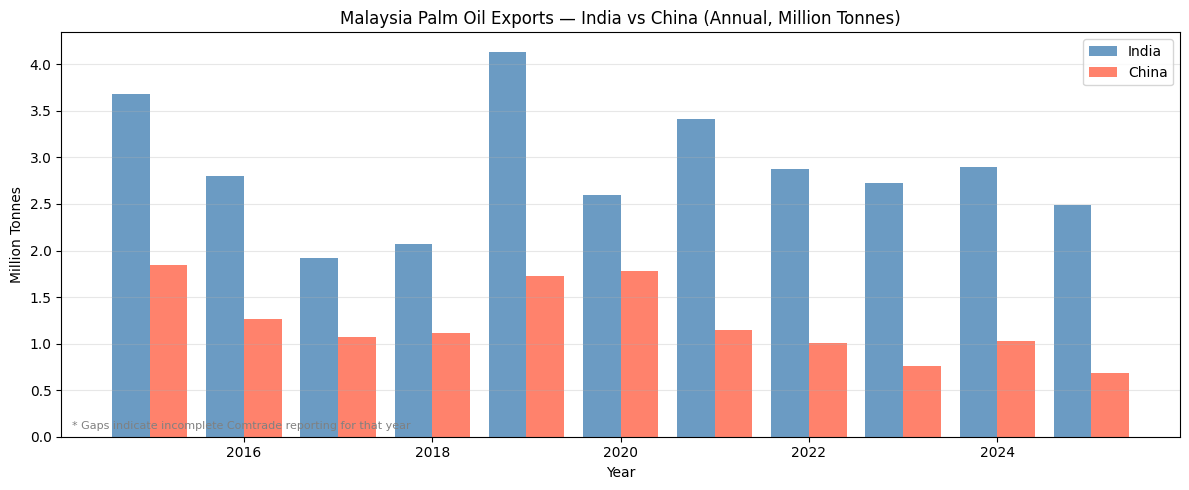

In [10]:
# Use only reliable rows for the chart
df_plot = df_exports.copy()
df_plot.loc[~df_plot["is_reliable"], "export_qty_tonnes"] = np.nan

fig, ax = plt.subplots(figsize=(12, 5))

for dest, color in [("India", "steelblue"), ("China", "tomato")]:
    subset = df_plot[df_plot["destination"] == dest]
    ax.bar(
        subset["year"] + (0.2 if dest == "China" else -0.2),
        subset["export_qty_tonnes"] / 1e6,   # convert to million tonnes
        width  = 0.4,
        label  = dest,
        color  = color,
        alpha  = 0.8
    )

ax.set_title("Malaysia Palm Oil Exports — India vs China (Annual, Million Tonnes)")
ax.set_ylabel("Million Tonnes")
ax.set_xlabel("Year")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
ax.annotate(
    "* Gaps indicate incomplete Comtrade reporting for that year",
    xy=(0.01, 0.02), xycoords="axes fraction",
    fontsize=8, color="gray"
)

plt.tight_layout()
plt.show()

## Notebook 03 — Findings & Decisions

**Source:** UN Comtrade API  
**Library:** `comtradeapicall` + direct `requests` to comtradeapi.un.org  
**Commodity:** HS 1511 (all palm oil — crude + refined)  
**Flow:** Malaysia (reporter) → India + China (partners), Exports only  
**Frequency:** Annual only — Malaysia does not submit monthly data to Comtrade  

---

### Country Codes — Always Verify, Never Assume

| Country | Code | Note |
|---|---|---|
| Malaysia (reporter) | 458 | Confirmed ✓ |
| India (partner) | 699 | NOT 356 — code 356 = "India (...1974)", expired |
| China (partner) | 156 | Confirmed ✓ |

Codes verified directly from official Comtrade reference files:
- https://comtradeapi.un.org/files/v1/app/reference/Reporters.json
- https://comtradeapi.un.org/files/v1/app/reference/partnerAreas.json

---

### Commodity Code Decision

Initially queried HS `151110` (crude palm oil only).  
China volumes returned near-zero — not reflective of real trade.  
Root cause: Malaysia exports mostly **refined** palm oil to China, not crude. India buys both crude and refined.

**Decision:** Broadened to HS `1511` (all palm oil) for both countries so India and China are compared on the same basis.

---

### Data Quality Issues Found and Fixed

**Issue 1 — Duplicate and aggregate records per year**  
Comtrade returns multiple rows per year representing:
- Sub-records (individual shipment classifications)
- An aggregate row that already sums the sub-records

Verified for 2019 China:
- Row A: 8,500 kg (small sub-record)
- Row B: 1,722,560,000 kg (main volume)
- Row C: 1,722,568,000 kg = Row A + Row B (the aggregate — correct total)

For 2022 China: two rows are fully identical true duplicates.

**Fix:** Sort descending by qty, then `drop_duplicates()` keeping the maximum row per year.  
Do NOT sum rows — the aggregate already includes everything.

**Issue 2 — Phantom near-zero values**  
Before fix, 2019 and 2025 China showed near-zero volumes because the phantom sub-record appeared before the real aggregate row. Fixed by sort-then-deduplicate approach above.

---

### Data Reliability — Important Caveats

Comtrade trade data should be treated as **directional indicators, not precise volumes.**  
Known sources of discrepancy vs other datasets:

- **Mirror statistics:** Malaysia records exports at FOB value. Destination countries record the same shipment at CIF value (includes freight/insurance). Difference is typically 10–15%.
- **Re-exports via Singapore:** Some Malaysia → China shipments transit Singapore and appear as Malaysia → Singapore → China in Comtrade, understating direct bilateral flows.
- **Estimation:** Most China records show `isReported=False`, `isAggregate=True` — Comtrade estimated these figures, Malaysia did not directly submit them.
- **Reporting lag:** Malaysia submits data late. Recent years (2024, 2025) may be incomplete or revised later.
- **HS code mapping differences:** Countries sometimes classify the same product under slightly different subcodes.

Cross-validation against MPOB total export data recommended in Notebook 07.  
Use Comtrade data for **trend analysis only.**

---

### Final Dataset

**Shape:** 22 rows (11 years × 2 countries)  
**Date range:** 2015–2025  
**Null values:** None  

**Columns for pipeline:**

| Column | Type | Description |
|---|---|---|
| year | int | Calendar year |
| destination | str | "India" or "China" |
| export_qty_tonnes | float | Palm oil export volume in tonnes |
| export_value_usd | float | FOB export value in USD |
| is_reliable | bool | False if volume below 500,000 tonnes threshold |

---

### Key Observations

- India is consistently the largest buyer: 2–4 million tonnes annually, roughly 2–3x China volumes every year
- India volumes dropped sharply 2016–2017, recovered from 2019 — likely correlated with India's import duty changes on Malaysian palm oil
- China volumes more stable: 0.75–1.84 million tonnes, less policy-driven
- 2025 China data present (~679,000 tonnes) but likely incomplete — treat as directional only
- Both countries peaked around 2015 and 2019–2021 — aligns with periods of low CPO prices (buyers stock up when prices are attractive)

---

**Next:** Notebook 04 — USDA FAS (Indonesia Supply/Demand)